In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np

# 1. NALOŽI BYCLASS PODATKE
print("Nalaganje byclass... filtriramo samo velike črke (razredi 10-35).")
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/byclass',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

Nalaganje byclass... filtriramo samo velike črke (razredi 10-35).


In [2]:
# 2. FUNKCIJA ZA FILTRIRANJE IN PRED-OBDELAVO
def filter_and_preprocess(image, label):
    # Normalize
    image = tf.cast(image, tf.float32) / 255.0
    # Popravek rotacije (EMNIST specifika)
    image = tf.transpose(image, perm=[1, 0, 2])
    # Prestavimo labele: A-Z so v byclass na indeksih 10-35
    # Nova labela bo stara_labela - 10 (torej A=0, B=1...)
    label = label - 10
    return image, label

# Filtriramo: obdržimo samo labele med 10 in 35
ds_train = ds_train.filter(lambda img, lbl: lbl >= 10 and lbl <= 35)
ds_test = ds_test.filter(lambda img, lbl: lbl >= 10 and lbl <= 35)

# Priprava pipeline-a
batch_size = 64
ds_train = ds_train.map(filter_and_preprocess).cache().shuffle(5000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(filter_and_preprocess).batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

In [3]:
# 3. ULTRA LAHEK MODEL ZA STM32 (Internal Flash < 128KB)
# Uporabljamo GlobalAveragePooling, da se znebimo ogromnih Dense plasti
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    
    # Prva konvolucija (8 filtrov)
    tf.keras.layers.Conv2D(8, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    # Druga konvolucija (16 filtrov)
    tf.keras.layers.Conv2D(16, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    # Namesto Flatten() uporabimo GlobalAveragePooling2D
    # To drastično zmanjša število parametrov!
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation='relu'), #to zakomentiraj da bo lažji za 10kb
        
    # Izhodna plast za 26 razredov (A-Z)
    tf.keras.layers.Dense(26, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 8)           │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 16)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 26)                  │           1,690 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,026 (15.73 KB)

 Trainable params: 4,026 (15.73 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 4. TRENIRANJE
model.fit(ds_train, epochs=20, validation_data=ds_test)

Epoch 1/20
   2933/Unknown 20s 6ms/step - accuracy: 0.2666 - loss: 2.5085

C:\Users\cam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2953/2953 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.3632 - loss: 2.1196 - val_accuracy: 0.4695 - val_loss: 1.7099
Epoch 2/20
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5638 - loss: 1.4081 - val_accuracy: 0.6032 - val_loss: 1.2457
Epoch 3/20
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6570 - loss: 1.1050 - val_accuracy: 0.6929 - val_loss: 0.9907
Epoch 4/20
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7196 - loss: 0.9145 - val_accuracy: 0.7442 - val_loss: 0.8413
Epoch 5/20
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7516 - loss: 0.8070 - val_accuracy: 0.7614 - val_loss: 0.7750
Epoch 6/20
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7719 - loss: 0.7394 - val_accuracy: 0.7693 - val_loss: 0.7417
Epoch 7/20
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7866 - loss: 0.6877 - val_accuracy: 0.7832 - val_loss: 0.6907
Epoch 8/20
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7996 - loss: 0.6474 - val_accura

In [5]:
# 5. PRETVORBA V TFLITE (Kvantizacija na 8-bit)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('small-emnist.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\cam\AppData\Local\Temp\tmp127el3po\assets


INFO:tensorflow:Assets written to: C:\Users\cam\AppData\Local\Temp\tmp127el3po\assets


Saved artifact at 'C:\Users\cam\AppData\Local\Temp\tmp127el3po'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  2085898774928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2085898779344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2087197922256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2087197922064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2085898774160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2085898780112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2087197923984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2087197923216: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [6]:
import os
print(f"Končna velikost modela za Flash: {os.path.getsize('small-emnist.tflite') / 1024:.2f} KB")

Končna velikost modela za Flash: 9.48 KB


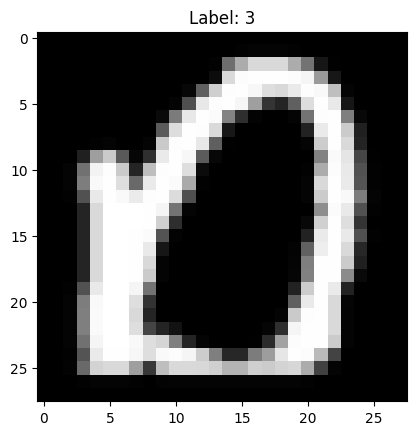

In [7]:
import matplotlib.pyplot as plt

for img, label in ds_train.take(1):
    plt.imshow(img[0], cmap='gray')
    plt.title(f"Label: {label[0].numpy()}")
    plt.show()

In [11]:
import struct

def export_emnist_benchmark(ds, filename="test_samples_bitmaps.bin", max_samples=40):
    count = 0

    with open(filename, "wb") as f:
        for batch_images, batch_labels in ds:
            images = batch_images.numpy()
            labels = batch_labels.numpy()

            for i in range(len(images)):
                if count >= max_samples:
                    break

                img = images[i]
                label = int(labels[i])

                # Flatten (28x28x1 → 784)
                pixels = img.astype(np.float32).flatten()

                # Sanity check
                assert len(pixels) == 784

                # Pack (B=uint8, H=uint16, 784f)
                data = struct.pack('<BH784f', label, 784, *pixels)
                f.write(data)

                count += 1

            if count >= max_samples:
                break

    print(f"Končano! {count} vzorcev shranjenih v '{filename}'")
    
export_emnist_benchmark(ds_test)

Končano! 40 vzorcev shranjenih v 'test_samples_bitmaps.bin'
